# Motif-Context Swap Experiment

Isolate motif syntax (MoDISco-annotated regions) from context (non-motif regions),
create chimeric sequences by swapping motif syntaxes into different contexts across
activity bins, predict with LegNet, and plot results.

In [2]:
"""Cell 1: Load data, extract seqlet annotations, merge overlapping intervals."""
import os
import sys
import numpy as np
import pandas as pd
import h5py
from pathlib import Path

BASE_DIR = '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/large_scale_swap'
FG_DIR = f'{BASE_DIR}/data/foregrounds'
MUT_DIR = f'{BASE_DIR}/data/mutagenesis_lib'
ACTIVITY_CSV = f'{BASE_DIR}/data/activity_lib/k562_activity_library.csv'
MODISCO_H5 = f'{BASE_DIR}/motif_context_swap/motif_annotation/modisco_results/modisco_foreground.h5'
MCS_DIR = f'{BASE_DIR}/motif_context_swap/mcs_experiment/mcs_library'
os.makedirs(MCS_DIR, exist_ok=True)

# Load activity library for seq_id -> bin mapping
activity_df = pd.read_csv(ACTIVITY_CSV, usecols=['seq_id', 'activity_bin'])
bin_map = dict(zip(activity_df['seq_id'], activity_df['activity_bin']))

# Collect WT one-hots (same loading as modisco_foreground.ipynb)
wt_onehots = []
loaded_ids = []

for seq_id in sorted(os.listdir(FG_DIR)):
    fg_path = f'{FG_DIR}/{seq_id}/foreground_scaled.npy'
    if not os.path.exists(fg_path) or os.path.getsize(fg_path) == 0:
        continue
    activity_bin = bin_map.get(seq_id)
    if activity_bin is None:
        continue
    mut_path = f'{MUT_DIR}/{activity_bin}_{seq_id}.h5'
    if not os.path.exists(mut_path):
        continue
    try:
        np.load(fg_path)  # verify foreground exists
    except:
        continue
    with h5py.File(mut_path, 'r') as f:
        wt_ohe = f['wt_sequence'][:].astype(np.float32)  # (230, 4)
    wt_onehots.append(wt_ohe)
    loaded_ids.append(seq_id)

wt_onehots = np.array(wt_onehots, dtype=np.float32)
print(f'Loaded {len(loaded_ids)} sequences, shape: {wt_onehots.shape}')

# Extract seqlet annotations from modisco h5
# Build: example_idx -> list of (start, end) intervals
raw_seqlets = {}  # example_idx -> [(start, end), ...]
with h5py.File(MODISCO_H5, 'r') as f:
    for group in ['pos_patterns', 'neg_patterns']:
        if group not in f:
            continue
        for pat_name in f[group]:
            sq = f[group][pat_name]['seqlets']
            for ex_idx, start, end in zip(sq['example_idx'][:], sq['start'][:], sq['end'][:]):
                raw_seqlets.setdefault(int(ex_idx), []).append((int(start), int(end)))

# Merge overlapping intervals per sequence
def merge_intervals(intervals):
    """Merge overlapping/adjacent intervals."""
    intervals = sorted(intervals)
    merged = [intervals[0]]
    for start, end in intervals[1:]:
        if start <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], end))
        else:
            merged.append((start, end))
    return merged

seq_motif_regions = {}  # example_idx -> [(start, end), ...]
for ex_idx, intervals in raw_seqlets.items():
    seq_motif_regions[ex_idx] = merge_intervals(intervals)

print(f'Sequences with annotations: {len(seq_motif_regions)}/{len(loaded_ids)}')

# Summary stats
n_regions = [len(v) for v in seq_motif_regions.values()]
region_sizes = [e - s for regions in seq_motif_regions.values() for s, e in regions]
print(f'Motif regions per seq: mean={np.mean(n_regions):.1f}, max={max(n_regions)}')
print(f'Region sizes (bp): mean={np.mean(region_sizes):.1f}, min={min(region_sizes)}, max={max(region_sizes)}')

Loaded 2893 sequences, shape: (2893, 230, 4)
Sequences with annotations: 954/2893
Motif regions per seq: mean=1.7, max=4
Region sizes (bp): mean=16.5, min=16, max=46


In [7]:
"""Cell 2: Build motif_syntax, context (motif-ablated), and controls for each annotated sequence.

Definitions:
  - motif_syntax: WT motifs at their relative positions, zeros elsewhere (the "donor" component)
  - context (motif-ablated): WT seq with motif regions replaced by the SAME positions from a
    dinucleotide shuffle of the FULL sequence. 50 replicates. This is the "recipient" base.
  - context_ablated (control): Fully dinuc-shuffled seq with WT motifs pasted back. 50 reps.
"""
import torch
from tangermeme.ersatz import dinucleotide_shuffle

N_SHUFFLES = 50
SEQ_LEN = 230
SEED = 42

seq_data = {}  # seq_id -> dict

annotated_indices = sorted(seq_motif_regions.keys())
print(f'Building components for {len(annotated_indices)} annotated sequences...')

for count, ex_idx in enumerate(annotated_indices):
    seq_id = loaded_ids[ex_idx]
    activity_bin = bin_map[seq_id]
    ohe = wt_onehots[ex_idx]  # (230, 4)
    regions = seq_motif_regions[ex_idx]

    # Build motif mask: True at motif positions
    motif_mask = np.zeros(SEQ_LEN, dtype=bool)
    for s, e in regions:
        motif_mask[s:e] = True

    # motif_syntax: zero out context, keep motifs at their positions
    motif_syntax = ohe.copy()
    motif_syntax[~motif_mask] = 0.0

    # Dinucleotide shuffle the FULL sequence (used for both context and context_ablated)
    ohe_torch = torch.from_numpy(ohe.T[np.newaxis]).float()  # (1, 4, 230)
    shuffled_full = dinucleotide_shuffle(ohe_torch, n=N_SHUFFLES, random_state=SEED + ex_idx)
    # (1, N_SHUFFLES, 4, 230) -> (N_SHUFFLES, 230, 4)
    shuffled_full = shuffled_full[0].numpy().transpose(0, 2, 1)

    # --- Context (motif-ablated): Start with WT, replace motif positions with
    #     the same positions from the dinuc-shuffled full sequence. ---
    context = np.tile(ohe[np.newaxis], (N_SHUFFLES, 1, 1))  # (50, 230, 4)
    for s, e in regions:
        context[:, s:e, :] = shuffled_full[:, s:e, :]

    # --- Context ablated (control): Start with dinuc-shuffled full seq,
    #     paste WT motifs back at motif positions. ---
    context_ablated = shuffled_full.copy()
    for s, e in regions:
        context_ablated[:, s:e, :] = ohe[s:e, :]

    seq_data[seq_id] = {
        'wt': ohe,
        'motif_syntax': motif_syntax,          # (230, 4) — donor motifs
        'context': context,                     # (50, 230, 4) — motif-ablated replicates
        'context_ablated': context_ablated,     # (50, 230, 4) — control
        'bin': activity_bin,
        'motif_regions': regions,
        'motif_mask': motif_mask,
        'ex_idx': ex_idx,
    }

    if (count + 1) % 200 == 0:
        print(f'  {count + 1}/{len(annotated_indices)} done')

print(f'Built seq_data for {len(seq_data)} sequences')
print(f'Bins: { {b: sum(1 for v in seq_data.values() if v["bin"]==b) for b in ["high","mid","low"]} }')

# Verify OHE validity
sample_id = list(seq_data.keys())[0]
ctx = seq_data[sample_id]['context']
ca = seq_data[sample_id]['context_ablated']
print(f'context row sums (should be 1): min={ctx.sum(axis=-1).min():.1f}, max={ctx.sum(axis=-1).max():.1f}')
print(f'context_ablated row sums (should be 1): min={ca.sum(axis=-1).min():.1f}, max={ca.sum(axis=-1).max():.1f}')

# Save WT and context_ablated sequences for use by other models (e.g. AGFT)
annotated_ids_ordered = [loaded_ids[i] for i in annotated_indices]
wt_arr = np.stack([seq_data[sid]['wt'] for sid in annotated_ids_ordered])
ca_arr = np.stack([seq_data[sid]['context_ablated'] for sid in annotated_ids_ordered])
np.savez_compressed(f'{MCS_DIR}/wt_sequences.npz', wt=wt_arr, seq_ids=annotated_ids_ordered)
np.savez_compressed(f'{MCS_DIR}/context_ablated_sequences.npz', context_ablated=ca_arr, seq_ids=annotated_ids_ordered)
print(f'Saved wt_sequences.npz: {wt_arr.shape}')
print(f'Saved context_ablated_sequences.npz: {ca_arr.shape}')

Building components for 954 annotated sequences...
  200/954 done
  400/954 done
  600/954 done
  800/954 done
Built seq_data for 954 sequences
Bins: {'high': 366, 'mid': 257, 'low': 331}
context row sums (should be 1): min=1.0, max=1.0
context_ablated row sums (should be 1): min=1.0, max=1.0
Saved wt_sequences.npz: (954, 230, 4)
Saved context_ablated_sequences.npz: (954, 50, 230, 4)


In [8]:
"""Cell 3: All-to-all motif-context swap — build chimeric sequences.

For each (donor, recipient) pair:
  - Take recipient's context (motif-ablated: WT context with motifs dinuc-shuffled, 50 reps)
  - Paste donor's motif_syntax at donor's motif positions
  - This creates chimeric seqs: donor motifs + recipient context (recipient motifs removed)

Group by (donor_bin, recipient_bin). Save to disk.
"""
from itertools import product

BINS = ['high', 'mid', 'low']

# Group seq_ids by bin
bin_seqs = {b: [sid for sid, d in seq_data.items() if d['bin'] == b] for b in BINS}
for b in BINS:
    print(f'{b}: {len(bin_seqs[b])} sequences')

# For tractability: sample up to N sequences per bin for the all-to-all
MAX_PER_BIN = 100  # 50 x 50 x 3 x 3 = 22500 pairs, each with 50 reps
rng = np.random.RandomState(42)

sampled_seqs = {}
for b in BINS:
    ids = bin_seqs[b]
    if len(ids) > MAX_PER_BIN:
        ids = list(rng.choice(ids, MAX_PER_BIN, replace=False))
    sampled_seqs[b] = ids
    print(f'Sampled {b}: {len(ids)}')

# Build chimeras
chimera_data = {}  # (donor_bin, recip_bin) -> list of (50, 230, 4) arrays

for donor_bin, recip_bin in product(BINS, BINS):
    chimeras = []
    for donor_id in sampled_seqs[donor_bin]:
        d = seq_data[donor_id]
        donor_motif_syntax = d['motif_syntax']  # (230, 4)
        donor_mask = d['motif_mask']  # (230,)

        for recip_id in sampled_seqs[recip_bin]:
            if donor_id == recip_id:
                continue
            r = seq_data[recip_id]
            # Use recipient's context (motif-ablated): WT context with motifs
            # replaced by dinuc shuffles. Recipient's motifs are already gone.
            base = r['context'].copy()  # (50, 230, 4)
            # Paste donor's motifs at donor's motif positions
            base[:, donor_mask, :] = donor_motif_syntax[donor_mask, :]
            chimeras.append(base)  # (50, 230, 4)

    chimera_data[(donor_bin, recip_bin)] = chimeras
    n_pairs = len(chimeras)
    print(f'({donor_bin} motifs, {recip_bin} context): {n_pairs} pairs')

# Save chimera library
for (db, rb), chimeras in chimera_data.items():
    if not chimeras:
        continue
    arr = np.stack(chimeras, axis=0)  # (n_pairs, 50, 230, 4)
    out_path = f'{MCS_DIR}/chimeras_{db}_motif_{rb}_context.npz'
    np.savez_compressed(out_path, chimeras=arr)
    print(f'Saved {out_path}: {arr.shape}')

print('\nDone building chimeras.')

high: 366 sequences
mid: 257 sequences
low: 331 sequences
Sampled high: 100
Sampled mid: 100
Sampled low: 100
(high motifs, high context): 9900 pairs
(high motifs, mid context): 10000 pairs
(high motifs, low context): 10000 pairs
(mid motifs, high context): 10000 pairs
(mid motifs, mid context): 9900 pairs
(mid motifs, low context): 10000 pairs
(low motifs, high context): 10000 pairs
(low motifs, mid context): 10000 pairs
(low motifs, low context): 9900 pairs
Saved /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/large_scale_swap/motif_context_swap/mcs_experiment/mcs_library/chimeras_high_motif_high_context.npz: (9900, 50, 230, 4)
Saved /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/large_scale_swap/motif_context_swap/mcs_experiment/mcs_library/chimeras_high_motif_mid_context.npz: (10000, 50, 230, 4)
Saved /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/large_scale_swap/motif_context_swap/mcs_experiment/mcs_library/chimeras_high_motif_low_context.npz: (10000,

In [4]:
"""Cell 4: LegNet ensemble predictions on WT, controls, and chimeric sequences."""
import glob as globmod
import gc

REPO_ROOT = Path('/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon')
sys.path.insert(0, str(REPO_ROOT / 'human_legnet'))
from trainer import LitModel, TrainingConfig

K562_MODEL_DIR = REPO_ROOT / '.weights/legnet_pretrained/final_dump/models/K562/md_shift_reverse_noavg_noch'
CONFIG_PATH = K562_MODEL_DIR / 'config.json'
CH_SWAP = [0, 2, 1, 3]  # ACGT -> AGCT

# Load all 10 fold models for ensemble prediction
train_cfg = TrainingConfig.from_json(str(CONFIG_PATH))
models = []
for fold in range(1, 11):
    pattern = str(K562_MODEL_DIR / f'best_model_test{fold}_val*.ckpt')
    cp = sorted(globmod.glob(pattern))[0]
    lit_model = LitModel.load_from_checkpoint(cp, tr_cfg=train_cfg)
    lit_model.eval()
    models.append(lit_model.model.cuda())
print(f'Loaded {len(models)} LegNet models (ensemble)')


def predict_legnet(ohe_acgt, models, batch_size=2048):
    """Ensemble prediction. Input: (N, 230, 4) ACGT numpy. Returns (N,) mean predictions."""
    x = ohe_acgt.transpose(0, 2, 1)[:, CH_SWAP, :]  # (N, 4, 230) AGCT
    ensemble = []
    with torch.no_grad():
        for m in models:
            preds = []
            for i in range(0, len(x), batch_size):
                batch = torch.from_numpy(x[i:i+batch_size]).float().cuda()
                preds.append(m(batch).cpu().numpy().flatten())
            ensemble.append(np.concatenate(preds))
    return np.mean(ensemble, axis=0).astype(np.float32)


# Predict on WT sequences (annotated only)
annotated_ids = list(seq_data.keys())
wt_arr = np.stack([seq_data[sid]['wt'] for sid in annotated_ids])  # (N, 230, 4)
wt_preds = predict_legnet(wt_arr, models)
for sid, pred in zip(annotated_ids, wt_preds):
    seq_data[sid]['wt_pred'] = float(pred)
print(f'WT predictions: {len(wt_preds)}, mean={wt_preds.mean():.4f}')
for b in ['high', 'mid', 'low']:
    vals = [seq_data[sid]['wt_pred'] for sid in annotated_ids if seq_data[sid]['bin'] == b]
    print(f'  {b}: n={len(vals)}, mean={np.mean(vals):.4f}')

# Predict on context (motif-ablated) controls — mean over 50 shuffles
print('Predicting motif-ablated context controls...')
for i, sid in enumerate(annotated_ids):
    ctx = seq_data[sid]['context']  # (50, 230, 4)
    ctx_preds = predict_legnet(ctx, models)
    seq_data[sid]['context_pred'] = float(ctx_preds.mean())
    if (i + 1) % 200 == 0:
        print(f'  {i + 1}/{len(annotated_ids)}')
print('Done context (motif-ablated).')

# Predict on context_ablated controls — mean over 50 shuffles
print('Predicting context-ablated controls...')
for i, sid in enumerate(annotated_ids):
    ca = seq_data[sid]['context_ablated']  # (50, 230, 4)
    ca_preds = predict_legnet(ca, models)
    seq_data[sid]['context_ablated_pred'] = float(ca_preds.mean())
    if (i + 1) % 200 == 0:
        print(f'  {i + 1}/{len(annotated_ids)}')
print('Done context_ablated.')

# Predict on chimeric sequences
print('\nPredicting chimeric sequences...')
chimera_preds = {}  # (donor_bin, recip_bin) -> array of mean predictions per pair

for (db, rb), chimeras in chimera_data.items():
    if not chimeras:
        chimera_preds[(db, rb)] = np.array([])
        continue
    pair_means = []
    for ci, chi in enumerate(chimeras):
        # chi: (50, 230, 4) — 50 shuffle replicates for one donor-recipient pair
        p = predict_legnet(chi, models)
        pair_means.append(p.mean())
        if (ci + 1) % 500 == 0:
            print(f'    ({db},{rb}): {ci+1}/{len(chimeras)}')
    chimera_preds[(db, rb)] = np.array(pair_means, dtype=np.float32)
    print(f'  ({db}, {rb}): {len(pair_means)} pairs, mean pred={np.mean(pair_means):.4f}')

print('Done all predictions.')

# Save predictions
pred_path = f'{MCS_DIR}/predictions.npz'
save_dict = {}
for (db, rb), preds in chimera_preds.items():
    save_dict[f'chimera_{db}_{rb}'] = preds

BINS = ['high', 'mid', 'low']
for b in BINS:
    sids = [sid for sid in annotated_ids if seq_data[sid]['bin'] == b]
    save_dict[f'wt_{b}'] = np.array([seq_data[sid]['wt_pred'] for sid in sids])
    save_dict[f'context_{b}'] = np.array([seq_data[sid]['context_pred'] for sid in sids])
    save_dict[f'context_ablated_{b}'] = np.array([seq_data[sid]['context_ablated_pred'] for sid in sids])

np.savez_compressed(pred_path, **save_dict)
print(f'Saved predictions: {pred_path}')

RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


high: n=193
mid: n=136
low: n=103
Excluded (in gap): 522
  rebinned (high, high): 3080 pairs
  rebinned (high, low): 1568 pairs
  rebinned (high, mid): 3080 pairs
  rebinned (low, high): 1568 pairs
  rebinned (low, low): 756 pairs
  rebinned (low, mid): 1540 pairs
  rebinned (mid, high): 3080 pairs
  rebinned (mid, low): 1540 pairs
  rebinned (mid, mid): 2970 pairs


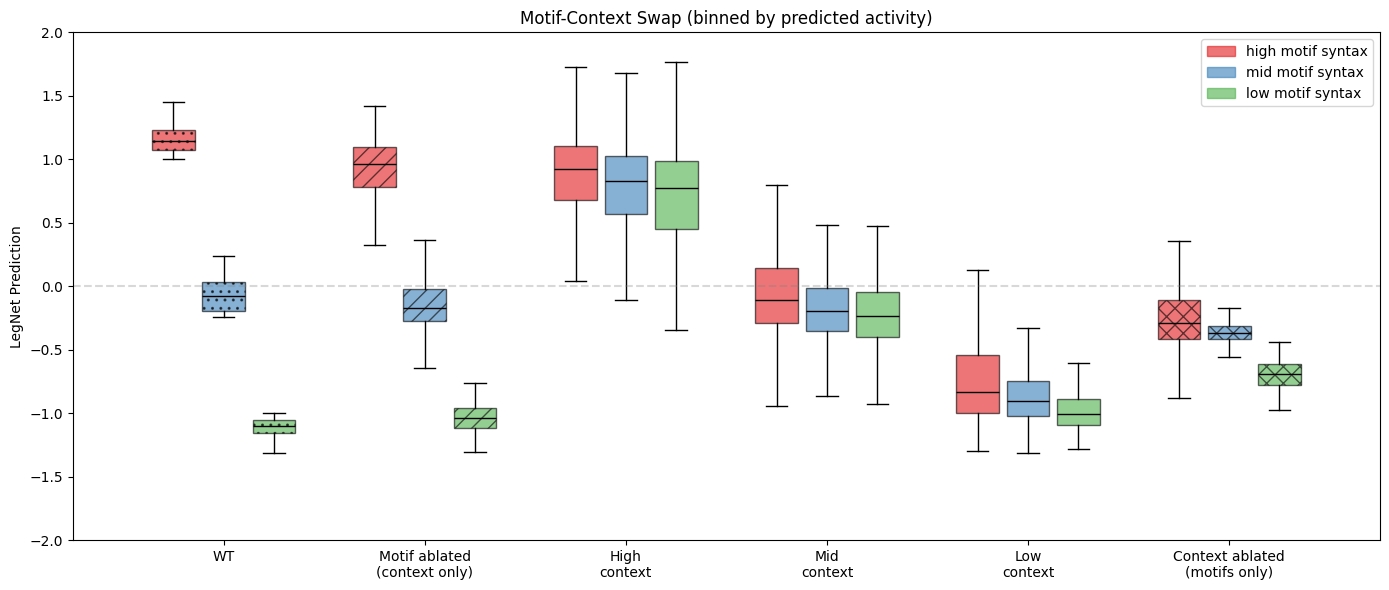

In [5]:
"""Cell 5: Re-bin by predicted activity, then plot.
Self-contained: loads saved predictions, no dependency on seq_data or model."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BASE_DIR = '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/large_scale_swap'
MCS_DIR = f'{BASE_DIR}/motif_context_swap/mcs_experiment/mcs_library'
ACTIVITY_CSV = f'{BASE_DIR}/data/activity_lib/k562_activity_library.csv'

preds = np.load(f'{MCS_DIR}/predictions.npz')
activity_df = pd.read_csv(ACTIVITY_CSV, usecols=['seq_id', 'activity_bin'])
bin_map = dict(zip(activity_df['seq_id'], activity_df['activity_bin']))

BINS = ['high', 'mid', 'low']
BIN_COLORS = {'high': '#e41a1c', 'mid': '#377eb8', 'low': '#4daf4a'}

wt_all = {}  # orig_bin -> array of wt preds
ca_all = {}  # orig_bin -> array of context_ablated preds
ma_all = {}  # orig_bin -> array of motif-ablated (context) preds
for b in BINS:
    wt_all[b] = preds[f'wt_{b}']
    ca_all[b] = preds[f'context_ablated_{b}']
    ma_all[b] = preds[f'context_{b}']

# Re-bin WT predictions: high >1, mid (-0.25, 0.25), low <-1
rebinned_wt = {b: [] for b in BINS}
rebinned_ca = {b: [] for b in BINS}
rebinned_ma = {b: [] for b in BINS}
orig_to_pred_bin = {}  # (orig_bin, idx) -> pred_bin
for orig_b in BINS:
    for i, p in enumerate(wt_all[orig_b]):
        if p > 1:
            pb = 'high'
        elif -0.25 <= p <= 0.25:
            pb = 'mid'
        elif p < -1:
            pb = 'low'
        else:
            continue
        rebinned_wt[pb].append(float(p))
        rebinned_ca[pb].append(float(ca_all[orig_b][i]))
        rebinned_ma[pb].append(float(ma_all[orig_b][i]))
        orig_to_pred_bin[(orig_b, i)] = pb

for b in BINS:
    print(f'{b}: n={len(rebinned_wt[b])}')
print(f'Excluded (in gap): {sum(len(wt_all[b]) for b in BINS) - sum(len(rebinned_wt[b]) for b in BINS)}')

# Reconstruct sampled_seqs indices for chimera rebinning
MAX_PER_BIN = 100
rng = np.random.RandomState(42)
sampled_indices = {}
for b in BINS:
    n = len(wt_all[b])
    if n > MAX_PER_BIN:
        sampled_indices[b] = list(rng.choice(n, MAX_PER_BIN, replace=False))
    else:
        sampled_indices[b] = list(range(n))

# Re-bin chimera predictions
chimera_preds_rebinned = {}
for orig_db in BINS:
    for orig_rb in BINS:
        key_name = f'chimera_{orig_db}_{orig_rb}'
        if key_name not in preds:
            continue
        pair_means = preds[key_name]
        d_indices = sampled_indices[orig_db]
        r_indices = sampled_indices[orig_rb]
        pair_idx = 0
        for di in d_indices:
            for ri in r_indices:
                if orig_db == orig_rb and di == ri:
                    continue
                d_pb = orig_to_pred_bin.get((orig_db, di))
                r_pb = orig_to_pred_bin.get((orig_rb, ri))
                if d_pb is not None and r_pb is not None:
                    key = (d_pb, r_pb)
                    chimera_preds_rebinned.setdefault(key, []).append(float(pair_means[pair_idx]))
                pair_idx += 1

for key in sorted(chimera_preds_rebinned):
    chimera_preds_rebinned[key] = np.array(chimera_preds_rebinned[key])
    print(f'  rebinned ({key[0]}, {key[1]}): {len(chimera_preds_rebinned[key])} pairs')

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
x_labels = ['WT', 'Motif ablated\n(context only)', 'High\ncontext', 'Mid\ncontext', 'Low\ncontext', 'Context ablated\n(motifs only)']
n_conditions = len(x_labels)
width = 0.25
offsets = {'high': -width, 'mid': 0, 'low': width}

for motif_bin in BINS:
    data = [
        rebinned_wt[motif_bin],
        rebinned_ma[motif_bin],
        list(chimera_preds_rebinned.get((motif_bin, 'high'), [])),
        list(chimera_preds_rebinned.get((motif_bin, 'mid'), [])),
        list(chimera_preds_rebinned.get((motif_bin, 'low'), [])),
        rebinned_ca[motif_bin],
    ]
    positions = [i + offsets[motif_bin] for i in range(n_conditions)]
    bp = ax.boxplot(data, positions=positions, widths=width * 0.85,
                    patch_artist=True, showfliers=False, medianprops=dict(color='black'))
    for ci, patch in enumerate(bp['boxes']):
        patch.set_facecolor(BIN_COLORS[motif_bin])
        patch.set_alpha(0.6)
        if ci == 0:
            patch.set_hatch('..')
            patch.set_edgecolor('black')
            patch.set_linewidth(1.0)
        elif ci == 1:
            patch.set_hatch('//')
            patch.set_edgecolor('black')
            patch.set_linewidth(1.0)
        elif ci == 5:
            patch.set_hatch('xx')
            patch.set_edgecolor('black')
            patch.set_linewidth(1.0)

ax.set_xticks(range(n_conditions))
ax.set_xticklabels(x_labels)
ax.set_ylim(-2, 2)
ax.set_ylabel('LegNet Prediction')
ax.set_title('Motif-Context Swap (binned by predicted activity)')
handles = [mpatches.Patch(color=BIN_COLORS[b], alpha=0.6, label=f'{b} motif syntax') for b in BINS]
ax.legend(handles=handles, loc='upper right')
ax.axhline(y=0, color='grey', linestyle='--', alpha=0.3)
fig.tight_layout()

#fig.savefig(f'{MCS_DIR}/human_motif_context_swap_plot_K562.png', dpi=150, bbox_inches='tight')
#print(f'Saved: {MCS_DIR}/human_motif_context_swap_plot_K562.png')

Chosen: peak2066_Reversed:, WT pred=1.103, regions=[(183, 199)]


/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/legnet_env/lib/python3.11/site-packages/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.2592, 0.3738, 0.1618, 0.2593, 0.1677, 0.3569, 0.3720, 0.3087, 0.3197,
        0.2168, 0.1615, 0.0796, 0.3824, 0.0111, 0.3128], device='cuda:0',
       grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +


Saved deepshap_example_high.png


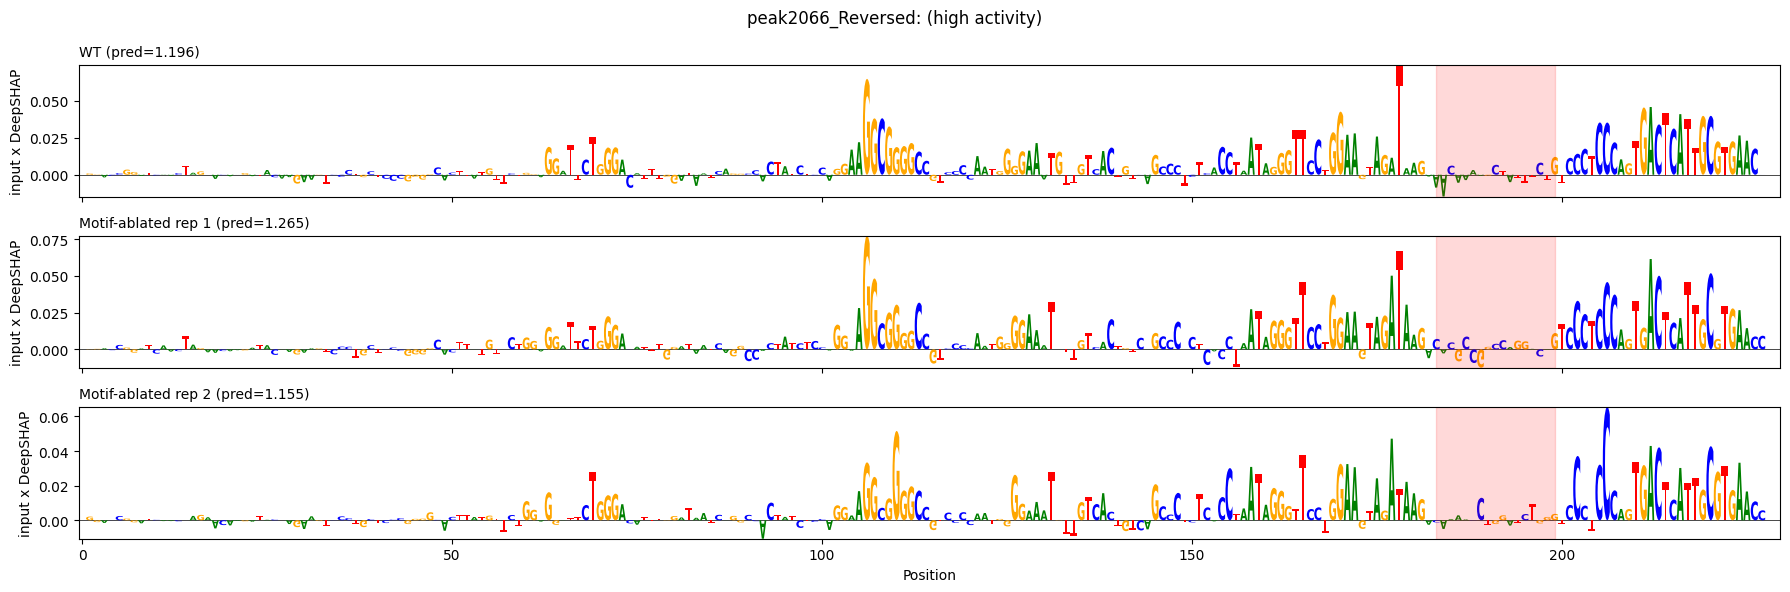

In [18]:
"""Cell 6: DeepLIFT/SHAP attribution logos for a random high-activity example.
Row 1: WT input×DeepSHAP with motif annotations
Row 2-3: Two motif-ablated replicates input×DeepSHAP
"""
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import sys, os, h5py
import pandas as pd

BASE_DIR = '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/large_scale_swap'
MCS_DIR = f'{BASE_DIR}/motif_context_swap/mcs_experiment/mcs_library'
MUT_DIR = f'{BASE_DIR}/data/mutagenesis_lib'
MODISCO_H5 = f'{BASE_DIR}/motif_context_swap/motif_annotation/modisco_results/modisco_foreground.h5'

REPO_ROOT = Path('/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon')
sys.path.insert(0, str(REPO_ROOT / 'human_legnet'))
from trainer import LitModel, TrainingConfig
from tangermeme.deep_lift_shap import deep_lift_shap
from tangermeme.ersatz import dinucleotide_shuffle
import glob as globmod
import logomaker

K562_MODEL_DIR = REPO_ROOT / '.weights/legnet_pretrained/final_dump/models/K562/md_shift_reverse_noavg_noch'
CONFIG_PATH = K562_MODEL_DIR / 'config.json'
CH_SWAP = [0, 2, 1, 3]  # ACGT -> AGCT

# Load one model for attributions
train_cfg = TrainingConfig.from_json(str(CONFIG_PATH))
cp = sorted(globmod.glob(str(K562_MODEL_DIR / 'best_model_test1_val*.ckpt')))[0]
lit_model = LitModel.load_from_checkpoint(cp, tr_cfg=train_cfg)
lit_model.eval()
raw_model = lit_model.model.cuda()

class WrappedModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x).unsqueeze(-1)

wrapped = WrappedModel(raw_model).eval()

# --- Use saved seq_ids to get correct mapping ---
activity_df = pd.read_csv(f'{BASE_DIR}/data/activity_lib/k562_activity_library.csv', usecols=['seq_id', 'activity_bin'])
bin_map = dict(zip(activity_df['seq_id'], activity_df['activity_bin']))

# Load saved annotated seq_ids (same order as predictions were saved)
wt_data = np.load(f'{MCS_DIR}/wt_sequences.npz', allow_pickle=True)
all_annotated_ids = list(wt_data['seq_ids'])
high_seq_ids = [sid for sid in all_annotated_ids if bin_map[sid] == 'high']

# Load motif regions from modisco, build seq_id -> regions mapping
# Need loaded_ids to map example_idx -> seq_id
FG_DIR = f'{BASE_DIR}/data/foregrounds'
loaded_ids = []
for seq_id in sorted(os.listdir(FG_DIR)):
    fg_path = f'{FG_DIR}/{seq_id}/foreground_scaled.npy'
    if not os.path.exists(fg_path) or os.path.getsize(fg_path) == 0:
        continue
    if bin_map.get(seq_id) is None:
        continue
    mut_path = f'{MUT_DIR}/{bin_map[seq_id]}_{seq_id}.h5'
    if not os.path.exists(mut_path):
        continue
    try:
        np.load(fg_path)
    except:
        continue
    loaded_ids.append(seq_id)

raw_seqlets = {}
with h5py.File(MODISCO_H5, 'r') as f:
    for group in ['pos_patterns', 'neg_patterns']:
        if group not in f:
            continue
        for pat_name in f[group]:
            sq = f[group][pat_name]['seqlets']
            for ex_idx, start, end in zip(sq['example_idx'][:], sq['start'][:], sq['end'][:]):
                raw_seqlets.setdefault(int(ex_idx), []).append((int(start), int(end)))

def merge_intervals(intervals):
    intervals = sorted(intervals)
    merged = [intervals[0]]
    for start, end in intervals[1:]:
        if start <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], end))
        else:
            merged.append((start, end))
    return merged

# Build seq_id -> motif_regions (not index-dependent)
sid_to_regions = {}
for ex_idx, intervals in raw_seqlets.items():
    if ex_idx < len(loaded_ids):
        sid_to_regions[loaded_ids[ex_idx]] = merge_intervals(intervals)

# Pick a random high-predicted sequence
preds = np.load(f'{MCS_DIR}/predictions.npz')
wt_high = preds['wt_high']
high_mask = wt_high > 1
chosen_idx = int(np.random.choice(np.where(high_mask)[0]))
seq_id = high_seq_ids[chosen_idx]
regions = sid_to_regions[seq_id]
wt_pred_val = float(wt_high[chosen_idx])
print(f'Chosen: {seq_id}, WT pred={wt_pred_val:.3f}, regions={regions}')

# Load WT one-hot
with h5py.File(f'{MUT_DIR}/{bin_map[seq_id]}_{seq_id}.h5', 'r') as f:
    wt_ohe = f['wt_sequence'][:].astype(np.float32)  # (230, 4) ACGT

# Build 2 motif-ablated replicates
motif_mask = np.zeros(230, dtype=bool)
for s, e in regions:
    motif_mask[s:e] = True

ohe_torch = torch.from_numpy(wt_ohe.T[np.newaxis]).float()  # (1, 4, 230)
shuffled = dinucleotide_shuffle(ohe_torch, n=2, random_state=None)
shuffled = shuffled[0].numpy().transpose(0, 2, 1)  # (2, 230, 4) ACGT

ma_reps = np.tile(wt_ohe[np.newaxis], (2, 1, 1))  # (2, 230, 4)
for s, e in regions:
    ma_reps[:, s:e, :] = shuffled[:, s:e, :]

# Stack all 3: WT + 2 motif-ablated
all_seqs_acgt = np.concatenate([wt_ohe[np.newaxis], ma_reps], axis=0)  # (3, 230, 4)
all_seqs_agct = all_seqs_acgt.transpose(0, 2, 1)[:, CH_SWAP, :]  # (3, 4, 230)

# Get predictions for titles
with torch.no_grad():
    pred_vals = raw_model(torch.from_numpy(all_seqs_agct).float().cuda()).cpu().numpy().flatten()

# Compute DeepLIFT/SHAP (5 shuffles for speed)
X = torch.from_numpy(all_seqs_agct).float()
refs = dinucleotide_shuffle(X, n=5, random_state=42)
attrs_agct = deep_lift_shap(wrapped, X, references=refs, target=0,
                            hypothetical=True, batch_size=512,
                            device='cuda', verbose=False)
attrs_agct = attrs_agct.cpu().numpy()  # (3, 4, 230)

# Convert to ACGT and input×attr
attrs_acgt = attrs_agct[:, CH_SWAP, :].transpose(0, 2, 1)  # (3, 230, 4)
input_x_attr = all_seqs_acgt * attrs_acgt  # (3, 230, 4)

# Plot
fig, axes = plt.subplots(3, 1, figsize=(18, 6), sharex=True)
titles = [
    f'WT (pred={pred_vals[0]:.3f})',
    f'Motif-ablated rep 1 (pred={pred_vals[1]:.3f})',
    f'Motif-ablated rep 2 (pred={pred_vals[2]:.3f})',
]

for row in range(3):
    ax = axes[row]
    df = pd.DataFrame(input_x_attr[row], columns=['A', 'C', 'G', 'T'])
    logomaker.Logo(df, ax=ax, color_scheme='classic')
    ax.set_ylabel('input x DeepSHAP')
    ax.set_title(titles[row], fontsize=10, loc='left')
    for s, e in regions:
        ax.axvspan(s, e, alpha=0.15, color='red', zorder=0)

axes[-1].set_xlabel('Position')
fig.suptitle(f'{seq_id} (high activity)', fontsize=12)
fig.tight_layout()
fig.savefig(f'{MCS_DIR}/../mcs_results/Legnet/deepshap_example_high.png', dpi=150, bbox_inches='tight')
print('Saved deepshap_example_high.png')